In [42]:
import os
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
from openalea.widgets.plantgl import *
from openalea.plantgl.all import Material, Color3, Scene, Viewer
from openalea.astk.sky_irradiance import sky_irradiance
from openalea.astk.sky_sources import caribu_light_sources, sky_sources

import sys
from operator import itemgetter
sys.path.append('../data')
from archi_dict import *

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.display import build_scene, display_scene
from openalea.archicrop.stand import agronomic_plot, compute_domain, regular
from openalea.archicrop.stics_io import get_stics_data
from openalea.archicrop.light_it import illuminate, mean_leaf_irradiance
from openalea.archicrop.viability import compute_viable_params
from openalea.archicrop.simulation import constrain_archi_params, param_sampling
from openalea.archicrop.stics_io import stics_weather_3d

%gui qt

In [43]:
tec_file='../data/usms_STICS/v11/inter-sorghum-maize_tec.xml'
sorghum_plant_file='../data/usms_STICS/v11/plant/sorgho_imp_M_v10_plt.xml'
maize_plant_file='../data/usms_STICS/v11/plant/corn_plt.xml'
sorghum_stics_output_file='../data/usms_STICS/v11/mod_spinter_sorghum_maize.sti'
maize_stics_output_file='../data/usms_STICS/v11/mod_sainter_sorghum_maize.sti'
weather_file = '../data/usms_STICS/v11/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [ ]:
end = -1

density, daily_dynamics_sorghum, _, _, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=sorghum_plant_file,  # Path to the STICS plant XML file
        stics_output_file=sorghum_stics_output_file,  # Path to the STICS output file
        end=end
    )

density, daily_dynamics_maize, _, _, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=maize_plant_file,  # Path to the STICS plant XML file
        stics_output_file=maize_stics_output_file,  # Path to the STICS output file
        end=end
    )

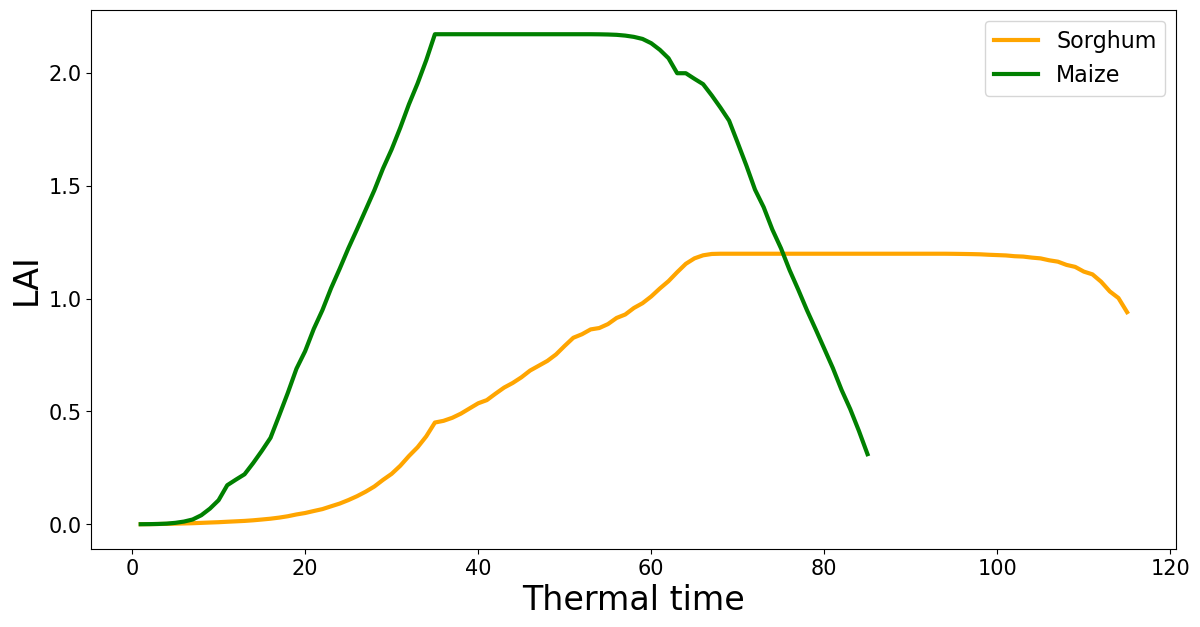

In [4]:
fig = plt.figure(figsize=(14, 7))

labels = ["Sorghum", "Maize"]
colors = ["orange", "green"]
dyn = [daily_dynamics_sorghum, daily_dynamics_maize]

for daily_dynamics, color, label in zip(dyn, colors, labels):
    thermal_time = [value["Thermal time"] for value in daily_dynamics.values()]
    leaf_area_plant = [value["Plant leaf area"] for value in daily_dynamics.values()]
    sen_leaf_area_plant = [value["Plant senescent leaf area"] for value in daily_dynamics.values()]
    height_canopy = [value["Plant height"] for value in daily_dynamics.values()]
    dae = range(1,len(thermal_time)+1)
    plt.plot(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=color, linewidth=3, label=label)
    # plt.plot(dae, [la*density/10000/2 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=color, linewidth=3, label=label)

plt.xlabel("Thermal time", fontsize=24)
plt.ylabel("LAI", fontsize=24)
plt.legend(fontsize=16)
plt.tick_params(labelsize=15)
plt.show()

In [49]:
def define_params(dynamics_file, plant_file, archi_params, end=-1):    
    # Retrieve STICS management and senescence parameters
    _, daily_dynamics, lifespan, lifespan_early, _ = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=plant_file,  # Path to the STICS plant XML file
        stics_output_file=dynamics_file,  # Path to the STICS output file
        end=end
    )

    pot_factor_lai = 3
    pot_factor_height = 3

    # Complete ArchiCrop parameters with values from constraint
    archi_params = constrain_archi_params(archi_params=archi_params, daily_dynamics=daily_dynamics, 
                                            lifespan=lifespan, lifespan_early=lifespan_early, 
                                            pot_factor_lai=pot_factor_lai, pot_factor_height=pot_factor_height)
    
    # Generate samples for ArchiCrop parameters 
    param_sets = param_sampling(archi_params=archi_params, n_samples=1)

    # Compute viable parameters wrt the dynamic constraint of LAI and height
    param_sets = compute_viable_params(
        params_sets=param_sets, 
        daily_dynamics=daily_dynamics, 
        pot_factor_lai=pot_factor_lai, pot_factor_height=pot_factor_height)
    
    return param_sets

In [6]:
params_sorghum = define_params(sorghum_stics_output_file, sorghum_plant_file, archi_sorghum, end=end)
sorghum = ArchiCrop(daily_dynamics=daily_dynamics_sorghum, **params_sorghum[1], plant_orientation=90)
sorghum.generate_potential_plant()
growing_sorghum = sorghum.grow_plant()

params_maize = define_params(maize_stics_output_file, maize_plant_file, archi_maize, end=end)
maize = ArchiCrop(daily_dynamics=daily_dynamics_maize, **params_maize[1], plant_orientation=90)
maize.generate_potential_plant()
growing_maize = maize.grow_plant()

[0.5        0.5037037  0.50740741 0.51111111 0.51481481 0.51851852
 0.52222222 0.52592593 0.52962963 0.53333333]
[0.5        0.50396825 0.50793651 0.51190476 0.51587302 0.51984127
 0.52380952 0.52777778 0.53174603 0.53571429]


In [7]:
params_sorghum

{1: {'nb_phy': 15,
  'nb_short_phy': 5,
  'short_phy_height': 3,
  'height': 283.59000000000003,
  'stem_q': 1,
  'diam_base': 4.0,
  'diam_top': 1.5,
  'leaf_area': 5994.0500999999995,
  'rmax': np.float64(0.5),
  'skew': np.float64(0.0),
  'wl': 0.12,
  'klig': 0.6,
  'swmax': 0.55,
  'f1': 0.64,
  'f2': 0.92,
  'insertion_angle': 60,
  'scurv': 0.75,
  'curvature': 90,
  'phyllotactic_angle': 180,
  'phyllotactic_deviation': 20,
  'phyllochron': 61.16469230769231,
  'stem_duration': 1.6,
  'leaf_duration': 1.6,
  'nb_tillers': 0,
  'tiller_angle': 20,
  'tiller_delay': 1,
  'reduction_factor': 0.5,
  'gravitropism_coefficient': 0.12,
  'leaf_lifespan': 280.0,
  'leaf_lifespan_early': 224.0}}

In [8]:
green=Color3((0,50,0))
day = 83
list_of_graphs = [growing_sorghum[day]]
# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

In [9]:
params_maize

{1: {'nb_phy': 28,
  'nb_short_phy': 5,
  'short_phy_height': 3,
  'height': 352.461,
  'stem_q': 1,
  'diam_base': 5.0,
  'diam_top': 1.5,
  'leaf_area': 10858.4499,
  'rmax': np.float64(0.5),
  'skew': np.float64(-8.715027513813988),
  'wl': 0.13,
  'klig': 0.6,
  'swmax': 0.55,
  'f1': 0.64,
  'f2': 0.92,
  'insertion_angle': 45,
  'scurv': 0.8,
  'curvature': 120,
  'phyllotactic_angle': 180,
  'phyllotactic_deviation': 20,
  'phyllochron': 48.348237762237765,
  'stem_duration': 1.6,
  'leaf_duration': 1.6,
  'nb_tillers': 0,
  'tiller_delay': 1,
  'tiller_angle': 30,
  'reduction_factor': 1,
  'gravitropism_coefficient': 0.05,
  'leaf_lifespan': 200.0,
  'leaf_lifespan_early': 200.0}}

In [28]:
# Rows
conv_coef = 100 # Convert from m to cm
inter_row = 0.7
inter_plant = 1.0 / inter_row / density
coord_maize_1 = (0,0,0)
coord_sorghum_1 = (0,inter_row * conv_coef,0) 
coord_sorghum_2 = (inter_plant * conv_coef,0,0)
coord_maize_2 = (inter_plant * conv_coef,inter_row * conv_coef,0) 
positions = [coord_maize_1] + [coord_sorghum_1] + [coord_maize_2] + [coord_sorghum_2]
print(inter_plant)
domain = ((0, -0.5 * inter_plant * conv_coef), (2 * inter_row * conv_coef, 1.5 * inter_plant * conv_coef))
lights=[(1,(0,0,-1))]
dates = [value["Date"] for value in daily_dynamics_sorghum.values()]

0.2380952380952381


In [29]:
green = Color3((0,50,0))
day = 65

width = 3
length = 3
nrow = max(1, int(round(float(width) / inter_row))) 
plant_per_row = max(1, int(round(float(length) / inter_plant)))

dx = inter_plant * conv_coef
dy = inter_row * conv_coef
positions_crop, domain = regular(
    nrow * plant_per_row, int(nrow), dx, dy, int(plant_per_row)
)
domain_area = (
    abs(domain[1][0] - domain[0][0]) / conv_coef
    * abs(domain[1][1] - domain[0][1]) / conv_coef
)

# sorting by ranks
positions_crop = sorted(positions_crop, key=itemgetter(1, 0))
print(positions_crop)

list_of_graphs = [growing_sorghum[day]] + [growing_maize[day]]

# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, positions_crop, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

[(11.904761904761905, 35.0, 0.0), (35.714285714285715, 35.0, 0.0), (59.523809523809526, 35.0, 0.0), (83.33333333333334, 35.0, 0.0), (107.14285714285714, 35.0, 0.0), (130.95238095238096, 35.0, 0.0), (154.76190476190476, 35.0, 0.0), (178.57142857142858, 35.0, 0.0), (202.38095238095238, 35.0, 0.0), (226.19047619047618, 35.0, 0.0), (250.0, 35.0, 0.0), (273.80952380952385, 35.0, 0.0), (297.61904761904765, 35.0, 0.0), (11.904761904761905, 105.0, 0.0), (35.714285714285715, 105.0, 0.0), (59.523809523809526, 105.0, 0.0), (83.33333333333334, 105.0, 0.0), (107.14285714285714, 105.0, 0.0), (130.95238095238096, 105.0, 0.0), (154.76190476190476, 105.0, 0.0), (178.57142857142858, 105.0, 0.0), (202.38095238095238, 105.0, 0.0), (226.19047619047618, 105.0, 0.0), (250.0, 105.0, 0.0), (273.80952380952385, 105.0, 0.0), (297.61904761904765, 105.0, 0.0), (11.904761904761905, 175.0, 0.0), (35.714285714285715, 175.0, 0.0), (59.523809523809526, 175.0, 0.0), (83.33333333333334, 175.0, 0.0), (107.14285714285714, 

In [30]:
green=Color3((0,50,0))
day = 80
# list_of_graphs = [growing_sorghum[day]] + [growing_maize[day]] 
# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

In [45]:
def simulation_cycle(dates, daily_dynamics, growing_plant1, growing_plant2, positions, domain, lights):

    green=Color3((0,50,0))

    results_cycle = {
            'scene': [],
            'cs': [],
            'raw': [],
            'agg': []
    }

    # Read weather data
    df_weather = stics_weather_3d(filename=weather_file, daily_dynamics=daily_dynamics)

    # Define incident PAR
    incident_rads = list(df_weather.itertuples())
    
    for day in range(1,len(dates)+1):
    # for day in range(80,85):
        list_of_graphs = []
        growing_plants = [growing_plant1, growing_plant2]
        for gp in growing_plants:
            if day not in gp:
                list_of_graphs.append(gp[max(gp)])
            else:
                list_of_graphs.append(gp[day])
        # list_of_graphs = [growing_plant1[day]] + [growing_plant2[day]] 

        incident_rad = incident_rads[day-1]
        par = incident_rad.rad * 0.48 * 0.95

        irr = sky_irradiance(daydate=incident_rad.daydate, day_ghi=par, **location)
        sun, sky = sky_sources(sky_type='clear_sky', sky_irradiance=irr, scale='global') #, source_irradiance='horizontal')
        lights = caribu_light_sources(sun, sky)
    
        scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=True)
        cs, raw, agg = illuminate(scene, light=lights, labels=labels, domain=domain, direct=False)
        agg = mean_leaf_irradiance(agg)

        results_cycle['scene'].append(scene)
        results_cycle['cs'].append(cs)
        results_cycle['raw'].append(raw)
        results_cycle['agg'].append(agg)

    return results_cycle


In [32]:
len(growing_sorghum)

115

In [33]:
len(growing_maize)

85

In [46]:
results_cycle = simulation_cycle(dates, daily_dynamics_sorghum, growing_sorghum, growing_maize, positions, domain, lights)

In [47]:
d = 50
sc, v=results_cycle['cs'][d].plot(results_cycle['raw'][d])

In [36]:
# energy_maize = [results_cycle['agg'][t].loc[0, 'Energy']*density/2 for t in range(5)]
# plt.plot(range(5), energy_maize, color='green')
# energy_sorghum = [results_cycle['agg'][t].loc[1, 'Energy']*density/2 for t in range(5)]
# plt.plot(range(5), energy_sorghum, color='orange')
# plt.plot(range(5), np.array(energy_sorghum) + np.array(energy_maize), color='black')
# plt.show()

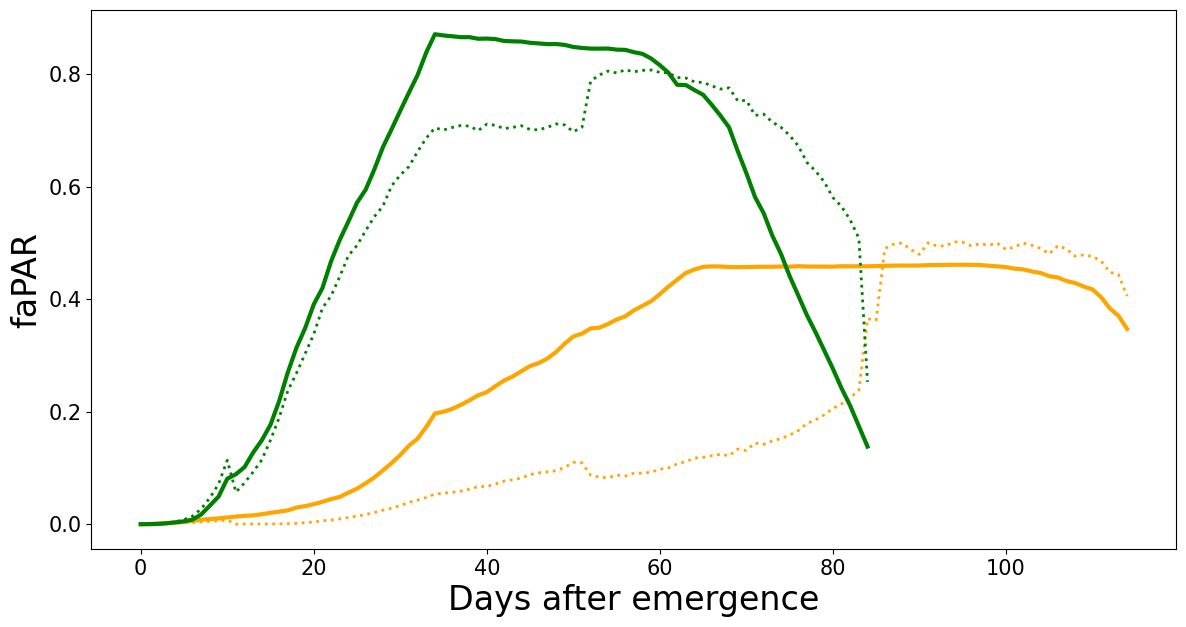

In [ ]:
fig = plt.figure(figsize=(14, 7))

for i, (daily_dynamics, color) in enumerate(zip(dyn, colors)):
    par_inc_stics = [value["Incident PAR"] for value in daily_dynamics.values()]
    par_caribu = [results_cycle['agg'][t].loc[i, 'Energy']*density/2/pinc for t,pinc in enumerate(par_inc_stics)]
    # if i == 0:
    #     par_caribu = [(results_cycle['agg'][t].loc[0, 'Energy']+results_cycle['agg'][t].loc[2, 'Energy'])*density/4 for t in range(len(dates))]
    # elif i == 1:
    #     par_caribu = [(results_cycle['agg'][t].loc[1, 'Energy']+results_cycle['agg'][t].loc[3, 'Energy'])*density/4 for t in range(len(dates))]
    # par_caribu = [results_cycle['agg'][t].loc[i, 'Energy']/(density/2) for t in range(len(dates))]
    plt.plot(range(len(par_caribu)), par_caribu, color=color, linewidth=3)
    par_stics = [value["Absorbed PAR"] for value in daily_dynamics.values()]
    plt.plot(range(len(par_stics)), par_stics, color=color, linewidth=2, linestyle=':')

plt.xlabel("Days after emergence", fontsize=24)
plt.ylabel("faPAR", fontsize=24)
# plt.legend(fontsize=16)
plt.tick_params(labelsize=15)

today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/abstract_FSPM_fig_1B_mix.png", dpi=1000)

plt.show()

In [41]:
results_cycle['agg'][80]

,Energy,area,Irradiance
plant,,,
0,0.093942,0.242754,0.386985
1,0.037948,0.135748,0.279548
2,0.002840,0.083624,0.033965
3,0.002276,0.059292,0.038389
